# Tutorial 5

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn as sk

[ 3.10550459 -0.19724771]


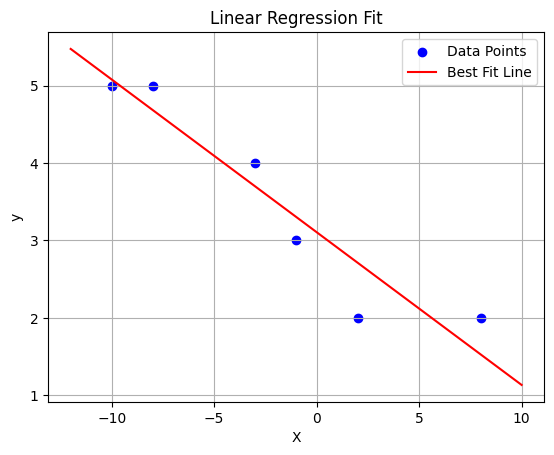

In [10]:
y = np.array([5,5,4,3,2,2])
X = np.array([[1,-10],[1,-8], [1,-3], [1,-1],[1,2],[1,8]])
w = np.linalg.inv(X.T @ X) @ X.T @ y
print(w)
plt.scatter(X[:,1], y, color='blue', label='Data Points')
x_line = np.linspace(-12, 10, 100)
y_line = w[0] + w[1] * x_line
plt.plot(x_line, y_line, color='red', label='Best Fit Line')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression Fit')
plt.legend()
plt.grid()
plt.show()

In [15]:
#Question 2:
y = np.array([1,2,3])
X_unweighted = np.array([[1,0,1],[2,-1,1],[1,1,5]])
w_unweighted = np.linalg.inv(X_unweighted.T @ X_unweighted) @ X_unweighted.T @ y
print("Unweighted Regression Coefficients:", w_unweighted)

X_weighted = np.array([[1,1,0,1],[1,2,-1,1],[1,1,1,5]])
w_weighted = X_weighted.T @ np.linalg.inv(X_weighted @ X_weighted.T) @ y
print("Weighted Regression Coefficients:", w_weighted)

Unweighted Regression Coefficients: [ 0.33333333 -0.66666667  0.66666667]
Weighted Regression Coefficients: [-0.14285714  0.52380952 -0.47619048  0.61904762]


Weighted Regression Coefficients: [9.3        0.67272727]


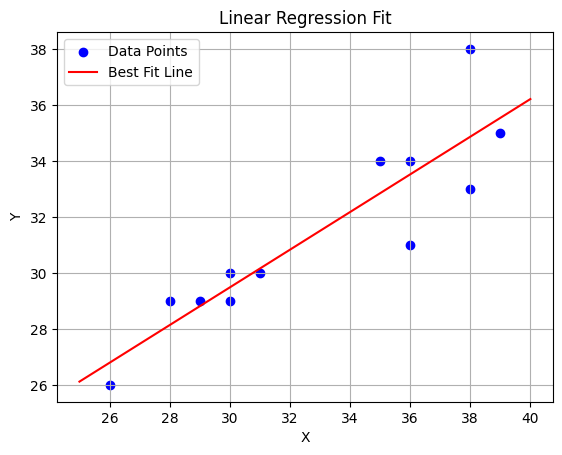

Predicted number of books for 30 students: 29.48181818181817
Predicted number of books for 5 students: 12.663636363636265


In [ ]:
#Question 3:

X = np.array([36,28,35,39,30,30,31,38,36,38,29,26])
Y = np.array([31,29,34,35,29,30,30,38,34,33,29,26])

plt.scatter(X, Y, color='blue', label='Data Points')

X_weighted = np.column_stack((np.ones(X.shape[0]), X))
w_weighted = np.linalg.inv(X_weighted.T @ X_weighted) @ X_weighted.T @ Y
print("Weighted Regression Coefficients:", w_weighted)

x_line = np.linspace(25, 40, 100)
y_line = w_weighted[0] + w_weighted[1] * x_line
plt.plot(x_line, y_line, color='red', label='Best Fit Line')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Linear Regression Fit')
plt.legend()
plt.grid()
plt.show()

#(c) predict number of books when 30 students have registered:
print("Predicted number of books for 30 students:", w_weighted[0] + w_weighted[1] * 30)

#(d) predict number of books when 5 students have registered:
print("Predicted number of books for 5 students:", w_weighted[0] + w_weighted[1] * 5)

Weighted Regression Coefficients: [-10.41257051   1.21434327]
Predicted number of books for 30 students (with duplicates): 26.017727639000807
Weighted Regression Coefficients (purged): [-5.6207265   1.09508547]
Predicted number of books for 30 students (purged): 27.231837606837626


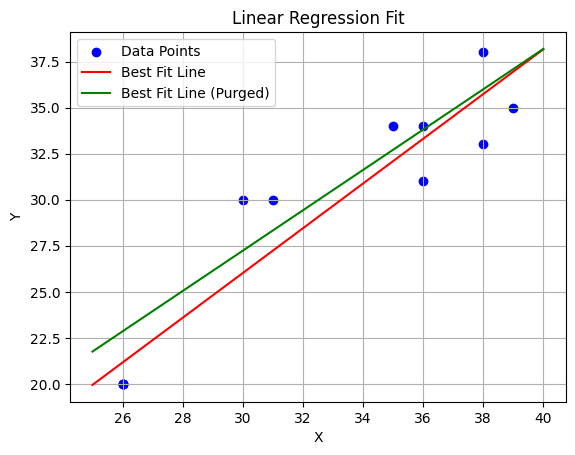

In [7]:
#Question 4:

X = np.array([36,26,35,39,26,30,31,38,36,38,26,26])
Y = np.array([31,20,34,35,20,30,30,38,34,33,20,20])

X_weighted = np.column_stack((np.ones(X.shape[0]), X))
w_weighted = np.linalg.inv(X_weighted.T @ X_weighted) @ X_weighted.T @ Y
print("Weighted Regression Coefficients:", w_weighted)

#Predict number of books when 30 students have registered (with duplicates):
print("Predicted number of books for 30 students (with duplicates):", w_weighted[0] + w_weighted[1] * 30)

#purge duplicates and recalculate regression coefficients:
X_purged = np.array([])
Y_purged = np.array([])
for i in range(len(X)):
    if X[i] not in X_purged:
        X_purged = np.append(X_purged, X[i])
        Y_purged = np.append(Y_purged, Y[i])

X_weighted_purged = np.column_stack((np.ones(X_purged.shape[0]), X_purged))
w_purged = np.linalg.inv(X_weighted_purged.T @ X_weighted_purged) @ X_weighted_purged.T @ Y_purged

print("Weighted Regression Coefficients (purged):", w_purged)
print("Predicted number of books for 30 students (purged):", w_purged[0] + w_purged[1] * 30)

plt.scatter(X, Y, color='blue', label='Data Points')

x_line = np.linspace(25, 40, 100)
y_line = w_weighted[0] + w_weighted[1] * x_line
plt.plot(x_line, y_line, color='red', label='Best Fit Line')
y_line_purged = w_purged[0] + w_purged[1] * x_line
plt.plot(x_line, y_line_purged, color='green', label='Best Fit Line (Purged)')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Linear Regression Fit')
plt.legend()
plt.grid()
plt.show()



In [9]:
#Question 5:

df = pd.read_csv('Tutorial 5 supp government-expenditure-on-education.csv')
X = df['year']
X = np.column_stack((np.ones(X.shape[0]), X))
y = df['recurrent_expenditure_total']

w = np.linalg.inv(X.T @ X) @ X.T @ y

print("Predicted expenditure in 2021: ", w[0] + w[1]*2021)


Predicted expenditure in 2021:  12102904.270643115


In [36]:
#Question 6:

wine = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv",sep=';')

y = wine.quality
x = wine.drop('quality', axis=1)

x_training = np.array(x[0:1500])
y_training = np.array(y[0:1500])
x_validation = np.array(x[1500:1600])
y_validation = np.array(y[1500:1600])

w = np.linalg.inv(x_training.T @ x_training) @ x_training.T @ y_training

print("Weights from regression: ", w)

y_val_pred = np.array([])

for i in range(len(x_validation)):
    y_val_pred = np.append(y_val_pred, x_validation[i]@w)

# print(y_val_pred)

SE = 0

for i in range(len(y_val_pred)):
    SE += (y_val_pred[i] - y_validation[i]) ** 2

MSE = SE/len(y_val_pred)

print("MSE: ", MSE)

# wine

Weights from regression:  [ 5.56713323e-03 -1.14472694e+00 -2.05931945e-01  2.64991100e-03
 -1.81647728e+00  4.51370125e-03 -3.25297209e-03  4.50664698e+00
 -5.09105679e-01  8.63731424e-01  2.98267022e-01]
MSE:  0.3437135463489905
